# Pricing Model 2: UKOIL and GOLD AND Contract

We are now pricing an **AND contract**. To make the settlement convention easier, this example uses **UKOIL and GOLD**, since both can be defined from daily futures-market closes with a matching expiry trading date.

The YES contract pays USD 1 only when both legs finish strictly above their own strikes. It pays USD 0 when either leg fails.

## The task

A user supplies two underlyings, two strikes, and one common expiry:

**Will UKOIL close above its strike AND GOLD close above its strike on the common expiry trading date?**

The model returns each marginal probability, their dependence estimate, the joint fair probability, risk diagnostics, and a two-sided combo quote.

## Assumptions in plain language

1. UKOIL maps to Yahoo Finance BZ=F, a rolling front-month Brent futures series in USD per barrel.
2. GOLD maps to Yahoo Finance GC=F, a rolling front-month COMEX gold futures series in USD per troy ounce.
3. Both legs use the latest completed daily Close for pricing and the same expiry trading date for settlement.
4. Daily Close histories are aligned by date before dependence is estimated.
5. Volatilities and correlation use an EWMA covariance matrix with lambda 0.94 and up to 180 paired returns.
6. Each marginal is a Black-Scholes-style digital probability with zero rate and carry.
7. The joint probability uses a Gaussian copula. It does not multiply the marginal probabilities unless correlation is zero.
8. The fair joint probability must satisfy the Frechet no-arbitrage bounds.
9. The quote applies an inventory skew and a dynamic half-spread for correlation, near-strike, and short-expiry risk.
10. Public continuous-futures data is useful for a sample, not a production settlement oracle.

In [37]:
import os
import math
import time
import tempfile
from dataclasses import dataclass

os.environ.setdefault('MPLCONFIGDIR', os.path.join(tempfile.gettempdir(), 'omnibook-matplotlib'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.stats import multivariate_normal, norm

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

## Visible configuration

Live Yahoo Finance OHLC is the default, matching Model 1 for UKOIL (BZ=F) and GOLD (GC=F). If a live request fails, the notebook falls back to deterministic paired sample data and labels the source; set USE_LIVE_DATA to False for an offline demonstration.

In [38]:
# Match Model 1: load the latest completed Yahoo Finance daily OHLC by default.
USE_LIVE_DATA = True

ASSET_CONFIG = {
    'UKOIL': {'symbol': 'BZ=F', 'annualization': 252, 'unit': 'USD per barrel'},
    'GOLD': {'symbol': 'GC=F', 'annualization': 252, 'unit': 'USD per troy ounce'},
}

EWMA_LAMBDA = 0.94
LOOKBACK_RETURNS = 180
MIN_PAIRED_RETURNS = 30
RISK_FREE_RATE = 0.0
CARRY = 0.0

BASE_HALF_SPREAD = 0.015
CORRELATION_STRESS = 0.10
NEAR_STRIKE_SPREAD = 0.010
SHORT_EXPIRY_SPREAD = 0.005
MAX_HALF_SPREAD = 0.10
INVENTORY_SKEW_PER_YES = 0.001
MAX_INVENTORY_SKEW = 0.05
TICK_SIZE = 0.01

# Edit these example strikes in one visible place before running the quote cell.
EXAMPLE_STRIKES = {
    'UKOIL': 120.0,
    'GOLD': 5_000.0,
}

ASSET_CONFIG

{'UKOIL': {'symbol': 'BZ=F', 'annualization': 252, 'unit': 'USD per barrel'},
 'GOLD': {'symbol': 'GC=F',
  'annualization': 252,
  'unit': 'USD per troy ounce'}}

## Market data and OHLC layout

This keeps the Model 1 layout: every asset has Open, High, Low, Close, a reference price, source text, and an observation timestamp. Pricing uses only completed Close values. The deterministic fallback generates the two series together so the sample has a known dependence structure.

In [39]:
@dataclass
class MarketData:
    underlying: str
    spot: float
    daily_ohlc: pd.DataFrame
    daily_closes: pd.Series
    source: str
    observed_at: pd.Timestamp


def _clean_ohlc(values: pd.DataFrame) -> pd.DataFrame:
    required = ['Open', 'High', 'Low', 'Close']
    if not set(required).issubset(values.columns):
        raise ValueError(f'OHLC data needs columns: {required}')
    frame = values[required].apply(pd.to_numeric, errors='coerce').dropna()
    frame = frame[(np.isfinite(frame)).all(axis=1) & (frame > 0).all(axis=1)]
    frame = frame[~frame.index.duplicated(keep='last')].sort_index()
    if len(frame) < MIN_PAIRED_RETURNS + 1:
        raise ValueError(f'Need at least {MIN_PAIRED_RETURNS + 1} valid OHLC rows')
    return frame


def fetch_yahoo_daily_ohlc(symbol: str) -> pd.DataFrame:
    url = f'https://query1.finance.yahoo.com/v8/finance/chart/{symbol}'
    params = {'range': '1y', 'interval': '1d', 'events': 'history'}
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, params=params, headers=headers, timeout=15)
    response.raise_for_status()
    result = response.json().get('chart', {}).get('result')
    if not result:
        raise ValueError(f'Yahoo Finance returned no daily data for {symbol}')
    item = result[0]
    quote_data = item['indicators']['quote'][0]
    index = pd.to_datetime(item['timestamp'], unit='s', utc=True)
    frame = pd.DataFrame({
        'Open': quote_data['open'],
        'High': quote_data['high'],
        'Low': quote_data['low'],
        'Close': quote_data['close'],
    }, index=index)
    regular = item.get('meta', {}).get('currentTradingPeriod', {}).get('regular', {})
    if regular and time.time() < regular.get('end', 0):
        session_start = pd.to_datetime(regular['start'], unit='s', utc=True)
        frame = frame[frame.index < session_start]
    return _clean_ohlc(frame)


def sample_ohlc_from_closes(closes: pd.Series, width: float = 0.004) -> pd.DataFrame:
    opens = closes.shift(1).fillna(closes.iloc[0])
    return pd.DataFrame({
        'Open': opens,
        'High': np.maximum(opens, closes) * (1 + width),
        'Low': np.minimum(opens, closes) * (1 - width),
        'Close': closes,
    }, index=closes.index)


def make_joint_sample_ohlc(count: int = 260, correlation: float = 0.25) -> dict:
    index = pd.date_range(end=pd.Timestamp.now(tz='UTC').normalize(), periods=count, freq='B')
    rng = np.random.default_rng(20261006)
    covariance = np.array([[1.0, correlation], [correlation, 1.0]])
    shocks = rng.multivariate_normal([0.0, 0.0], covariance, size=count)
    settings = {'UKOIL': (82.0, 0.34), 'GOLD': (2_700.0, 0.19)}
    result = {}
    for column, asset in enumerate(['UKOIL', 'GOLD']):
        start, annual_vol = settings[asset]
        daily = -0.5 * annual_vol**2 / 252 + annual_vol / math.sqrt(252) * shocks[:, column]
        closes = pd.Series(start * np.exp(np.cumsum(daily)), index=index, name=asset)
        result[asset] = sample_ohlc_from_closes(closes)
    return result


SAMPLE_OHLC = make_joint_sample_ohlc()


def load_market_data(underlying: str, use_live: bool = False) -> MarketData:
    asset = underlying.upper()
    if asset not in ASSET_CONFIG:
        raise ValueError(f'Underlying must be one of {list(ASSET_CONFIG)}')
    if use_live:
        try:
            symbol = ASSET_CONFIG[asset]['symbol']
            ohlc = fetch_yahoo_daily_ohlc(symbol)
            return MarketData(asset, float(ohlc['Close'].iloc[-1]), ohlc, ohlc['Close'],
                              f'Yahoo Finance {symbol} completed daily OHLC', pd.Timestamp(ohlc.index[-1]))
        except Exception as error:
            print(f'{asset} live request failed; using sample data. Reason: {error}')
    ohlc = SAMPLE_OHLC[asset].copy()
    return MarketData(asset, float(ohlc['Close'].iloc[-1]), ohlc, ohlc['Close'],
                      'Deterministic paired sample data for offline review', pd.Timestamp(ohlc.index[-1]))


MARKET_DATA = {asset: load_market_data(asset, USE_LIVE_DATA) for asset in ASSET_CONFIG}

,reference_price,observations,history_start,history_end,stored_fields,source
underlying,,,,,,
UKOIL,100.320000,251,2025-10-06 04:00:00+00:00,2026-10-05 04:00:00+00:00,"Open, High, Low, Close",Yahoo Finance BZ=F completed daily OHLC
GOLD,"4,156.799805",251,2025-10-06 04:00:00+00:00,2026-10-05 04:00:00+00:00,"Open, High, Low, Close",Yahoo Finance GC=F completed daily OHLC


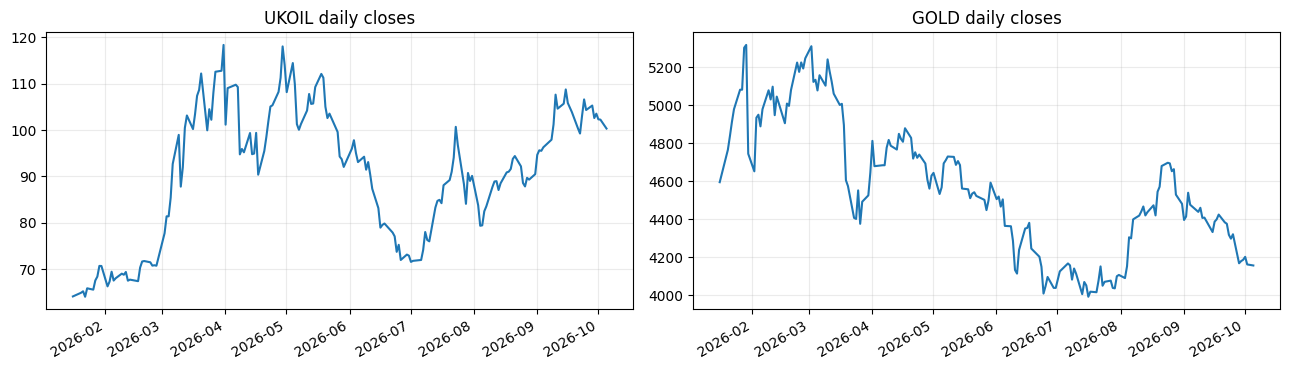

In [40]:
data_summary = pd.DataFrame([
    {
        'underlying': asset,
        'reference_price': data.spot,
        'observations': len(data.daily_ohlc),
        'history_start': data.daily_ohlc.index[0],
        'history_end': data.daily_ohlc.index[-1],
        'stored_fields': 'Open, High, Low, Close',
        'source': data.source,
    }
    for asset, data in MARKET_DATA.items()
]).set_index('underlying')
display(data_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for axis, (asset, data) in zip(axes, MARKET_DATA.items()):
    data.daily_closes.tail(180).plot(ax=axis, linewidth=1.5)
    axis.set_title(f'{asset} daily closes')
    axis.set_xlabel('')
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Aligned EWMA volatility and correlation

Correlation is meaningful only for returns observed over matching periods. The next function normalizes both histories to UTC dates, takes the inner join, computes paired log returns, and updates the complete 2 by 2 covariance matrix with EWMA. The diagonal produces annualized volatilities; the off-diagonal produces correlation.

In [41]:
def _daily_close_by_date(values: pd.Series, name: str) -> pd.Series:
    series = pd.Series(values, dtype=float).dropna()
    series = series[np.isfinite(series) & (series > 0)]
    index = pd.DatetimeIndex(series.index)
    index = index.tz_localize('UTC') if index.tz is None else index.tz_convert('UTC')
    series.index = index.normalize()
    return series.groupby(level=0).last().sort_index().rename(name)


def estimate_joint_ewma(
    first: pd.Series,
    second: pd.Series,
    lookback: int = LOOKBACK_RETURNS,
    decay: float = EWMA_LAMBDA,
    annualization: int = 252,
) -> dict:
    if not 0 < decay < 1:
        raise ValueError('EWMA decay must be between zero and one')
    levels = pd.concat([
        _daily_close_by_date(first, 'UKOIL'),
        _daily_close_by_date(second, 'GOLD'),
    ], axis=1, join='inner').dropna()
    returns = np.log(levels / levels.shift(1)).dropna().tail(lookback)
    if len(returns) < MIN_PAIRED_RETURNS:
        raise ValueError(f'Need at least {MIN_PAIRED_RETURNS} paired returns')

    seed_count = min(20, max(2, len(returns) // 4))
    covariance = returns.iloc[:seed_count].cov().to_numpy(dtype=float)
    for row in returns.iloc[seed_count:].to_numpy(dtype=float):
        covariance = decay * covariance + (1 - decay) * np.outer(row, row)

    variances = np.diag(covariance)
    if np.any(~np.isfinite(variances)) or np.any(variances <= 0):
        raise ValueError('EWMA covariance matrix is invalid')
    volatilities = np.sqrt(variances * annualization)
    correlation = covariance[0, 1] / math.sqrt(variances[0] * variances[1])
    correlation = float(np.clip(correlation, -0.95, 0.95))
    return {
        'aligned_levels': levels,
        'paired_returns': returns,
        'daily_covariance': covariance,
        'volatility_ukoil': float(volatilities[0]),
        'volatility_gold': float(volatilities[1]),
        'correlation': correlation,
    }


JOINT_ESTIMATE = estimate_joint_ewma(
    MARKET_DATA['UKOIL'].daily_closes,
    MARKET_DATA['GOLD'].daily_closes,
)

display(pd.Series({
    'paired_returns': len(JOINT_ESTIMATE['paired_returns']),
    'UKOIL annualized EWMA volatility': JOINT_ESTIMATE['volatility_ukoil'],
    'GOLD annualized EWMA volatility': JOINT_ESTIMATE['volatility_gold'],
    'EWMA correlation': JOINT_ESTIMATE['correlation'],
}, name='joint estimate'))

paired_returns                     180.000000
UKOIL annualized EWMA volatility     0.402875
GOLD annualized EWMA volatility      0.201859
EWMA correlation                    -0.257665
Name: joint estimate, dtype: float64

## Marginal and joint fair probability

Each leg first receives a digital probability p = N(d2). If z1 = NormalPPF(p1) and z2 = NormalPPF(p2), the Gaussian-copula AND probability is the bivariate normal CDF evaluated at z1 and z2 with correlation rho.

At rho = 0 this equals p1 times p2. Positive dependence generally makes two simultaneous high outcomes more likely than independence; negative dependence makes them less likely. The result is checked against the exact Frechet bounds.

In [42]:
def to_utc_timestamp(value) -> pd.Timestamp:
    timestamp = pd.Timestamp(value)
    return timestamp.tz_localize('UTC') if timestamp.tzinfo is None else timestamp.tz_convert('UTC')


def time_to_expiry_years(expiry, valuation_time=None) -> float:
    end = to_utc_timestamp(expiry)
    now = to_utc_timestamp(valuation_time or pd.Timestamp.now(tz='UTC'))
    seconds = (end - now).total_seconds()
    if seconds <= 0:
        raise ValueError('Expiry must be after valuation time')
    return seconds / (365.0 * 24 * 60 * 60)


def digital_probability(
    spot: float,
    strike: float,
    time_years: float,
    volatility: float,
    risk_free_rate: float = RISK_FREE_RATE,
    carry: float = CARRY,
) -> float:
    values = [spot, strike, time_years, volatility]
    if not all(math.isfinite(float(value)) and float(value) > 0 for value in values):
        raise ValueError('Spot, strike, time, and volatility must be positive finite numbers')
    d2 = (math.log(spot / strike) + (risk_free_rate - carry - 0.5 * volatility**2) * time_years) / (volatility * math.sqrt(time_years))
    return float(np.clip(norm.cdf(d2), 0.0, 1.0))


def frechet_bounds(probability_one: float, probability_two: float) -> tuple[float, float]:
    lower = max(0.0, probability_one + probability_two - 1.0)
    upper = min(probability_one, probability_two)
    return lower, upper


def gaussian_and_probability(probability_one: float, probability_two: float, correlation: float) -> float:
    if not 0 <= probability_one <= 1 or not 0 <= probability_two <= 1:
        raise ValueError('Marginal probabilities must be between zero and one')
    if not -1 < correlation < 1:
        raise ValueError('Correlation must be strictly between -1 and 1')
    epsilon = 1e-12
    z_values = [norm.ppf(np.clip(probability_one, epsilon, 1 - epsilon)),
                norm.ppf(np.clip(probability_two, epsilon, 1 - epsilon))]
    joint = float(multivariate_normal.cdf(z_values, mean=[0.0, 0.0],
                                           cov=[[1.0, correlation], [correlation, 1.0]]))
    lower, upper = frechet_bounds(probability_one, probability_two)
    if joint < lower - 1e-8 or joint > upper + 1e-8:
        raise ArithmeticError('Joint probability violates Frechet bounds')
    return float(np.clip(joint, lower, upper))

## Bid, ask, inventory, and risk buffers

The quote midpoint begins at fair value. Positive inventory means the market maker is long YES, so both quotes shift down; negative inventory shifts them up. The half-spread adds:

- a base charge;
- the half-range of fair values under a plus or minus 0.10 correlation stress;
- a near-strike charge that is largest when both marginal probabilities are near 50 percent; and
- a short-expiry charge.

The numerical cross-gamma diagnostic measures how the joint probability bends when both spots move together. It is reported rather than directly calibrated into the spread.

In [43]:
def _floor_to_tick(value: float, tick: float) -> float:
    return math.floor((value + 1e-12) / tick) * tick


def _ceil_to_tick(value: float, tick: float) -> float:
    return math.ceil((value - 1e-12) / tick) * tick


def risk_half_spread(p1: float, p2: float, correlation: float, time_years: float) -> dict:
    low_rho = max(-0.95, correlation - CORRELATION_STRESS)
    high_rho = min(0.95, correlation + CORRELATION_STRESS)
    low_value = gaussian_and_probability(p1, p2, low_rho)
    high_value = gaussian_and_probability(p1, p2, high_rho)
    correlation_charge = 0.5 * abs(high_value - low_value)
    near_strike_score = 4.0 * math.sqrt(p1 * (1 - p1) * p2 * (1 - p2))
    near_strike_charge = NEAR_STRIKE_SPREAD * near_strike_score
    days = max(time_years * 365.0, 1e-9)
    short_expiry_charge = SHORT_EXPIRY_SPREAD * min(1.0, math.sqrt(7.0 / days))
    total = min(MAX_HALF_SPREAD, BASE_HALF_SPREAD + correlation_charge + near_strike_charge + short_expiry_charge)
    return {
        'base': BASE_HALF_SPREAD,
        'correlation_charge': correlation_charge,
        'near_strike_charge': near_strike_charge,
        'short_expiry_charge': short_expiry_charge,
        'total': total,
    }


def make_combo_bid_ask(fair: float, p1: float, p2: float, correlation: float,
                       time_years: float, inventory_yes: float = 0.0) -> dict:
    lower, upper = frechet_bounds(p1, p2)
    if not lower - 1e-10 <= fair <= upper + 1e-10:
        raise ValueError('Fair value is outside the AND no-arbitrage bounds')
    inventory_skew = float(np.clip(-inventory_yes * INVENTORY_SKEW_PER_YES,
                                   -MAX_INVENTORY_SKEW, MAX_INVENTORY_SKEW))
    quote_mid = float(np.clip(fair + inventory_skew, 0.0, 1.0))
    spread = risk_half_spread(p1, p2, correlation, time_years)
    raw_bid = max(0.0, quote_mid - spread['total'])
    raw_ask = min(1.0, quote_mid + spread['total'])
    bid = float(np.clip(_floor_to_tick(raw_bid, TICK_SIZE), 0.0, 1.0))
    ask = float(np.clip(_ceil_to_tick(raw_ask, TICK_SIZE), 0.0, 1.0))
    return {
        'quote_mid_after_inventory': quote_mid,
        'inventory_skew': inventory_skew,
        'half_spread': spread['total'],
        'spread_components': spread,
        'bid': round(bid, 10),
        'ask': round(ask, 10),
    }


def joint_probability_from_spots(spot_ukoil: float, spot_gold: float, strike_ukoil: float,
                                 strike_gold: float, time_years: float, vol_ukoil: float,
                                 vol_gold: float, correlation: float) -> float:
    p_ukoil = digital_probability(spot_ukoil, strike_ukoil, time_years, vol_ukoil)
    p_gold = digital_probability(spot_gold, strike_gold, time_years, vol_gold)
    return gaussian_and_probability(p_ukoil, p_gold, correlation)


def numerical_cross_gamma(spot_ukoil: float, spot_gold: float, strike_ukoil: float,
                          strike_gold: float, time_years: float, vol_ukoil: float,
                          vol_gold: float, correlation: float, relative_step: float = 0.005) -> float:
    h1, h2 = spot_ukoil * relative_step, spot_gold * relative_step
    def value(s1, s2):
        return joint_probability_from_spots(s1, s2, strike_ukoil, strike_gold, time_years,
                                            vol_ukoil, vol_gold, correlation)
    mixed_difference = value(spot_ukoil + h1, spot_gold + h2) - value(spot_ukoil + h1, spot_gold - h2)
    mixed_difference -= value(spot_ukoil - h1, spot_gold + h2) - value(spot_ukoil - h1, spot_gold - h2)
    return mixed_difference / (4.0 * h1 * h2)

## Complete Model 2 quote function

This is the main entry point. The public interface accepts two strikes, one common expiry, an optional valuation time, and optional YES inventory.

In [44]:
def quote_and_contract(strike_ukoil: float, strike_gold: float, expiry,
                       valuation_time=None, inventory_yes: float = 0.0) -> dict:
    for name, strike in [('UKOIL', strike_ukoil), ('GOLD', strike_gold)]:
        if not math.isfinite(float(strike)) or float(strike) <= 0:
            raise ValueError(f'{name} strike must be a positive finite number')
    if not math.isfinite(float(inventory_yes)):
        raise ValueError('Inventory must be finite')

    years = time_to_expiry_years(expiry, valuation_time)
    estimate = estimate_joint_ewma(MARKET_DATA['UKOIL'].daily_closes,
                                   MARKET_DATA['GOLD'].daily_closes)
    p_ukoil = digital_probability(MARKET_DATA['UKOIL'].spot, float(strike_ukoil), years,
                                   estimate['volatility_ukoil'])
    p_gold = digital_probability(MARKET_DATA['GOLD'].spot, float(strike_gold), years,
                                 estimate['volatility_gold'])
    fair = gaussian_and_probability(p_ukoil, p_gold, estimate['correlation'])
    lower, upper = frechet_bounds(p_ukoil, p_gold)
    quote = make_combo_bid_ask(fair, p_ukoil, p_gold, estimate['correlation'], years, inventory_yes)
    cross_gamma = numerical_cross_gamma(
        MARKET_DATA['UKOIL'].spot, MARKET_DATA['GOLD'].spot,
        float(strike_ukoil), float(strike_gold), years,
        estimate['volatility_ukoil'], estimate['volatility_gold'], estimate['correlation'])
    scaled_cross_gamma = cross_gamma * MARKET_DATA['UKOIL'].spot * MARKET_DATA['GOLD'].spot * 0.01**2

    return {
        'contract': 'UKOIL above strike AND GOLD above strike',
        'expiry_utc': to_utc_timestamp(expiry).isoformat(),
        'time_to_expiry_years': years,
        'spot_ukoil': MARKET_DATA['UKOIL'].spot,
        'strike_ukoil': float(strike_ukoil),
        'volatility_ukoil': estimate['volatility_ukoil'],
        'probability_ukoil': p_ukoil,
        'spot_gold': MARKET_DATA['GOLD'].spot,
        'strike_gold': float(strike_gold),
        'volatility_gold': estimate['volatility_gold'],
        'probability_gold': p_gold,
        'ewma_correlation': estimate['correlation'],
        'independence_probability': p_ukoil * p_gold,
        'frechet_lower_bound': lower,
        'frechet_upper_bound': upper,
        'fair_probability': fair,
        'inventory_yes': float(inventory_yes),
        'inventory_skew': quote['inventory_skew'],
        'quote_mid_after_inventory': quote['quote_mid_after_inventory'],
        'half_spread': quote['half_spread'],
        'spread_components': quote['spread_components'],
        'bid': quote['bid'],
        'ask': quote['ask'],
        'cross_gamma_per_price_units': cross_gamma,
        'joint_effect_of_two_1pct_spot_moves': scaled_cross_gamma,
        'paired_return_observations': len(estimate['paired_returns']),
        'data_sources': {asset: data.source for asset, data in MARKET_DATA.items()},
        'model': 'correlated_lognormal_digitals_with_gaussian_copula',
    }

In [45]:
valuation_time = pd.Timestamp.now(tz='UTC')
example_expiry = (valuation_time + pd.Timedelta(days=90)).normalize()
if example_expiry <= valuation_time:
    example_expiry += pd.Timedelta(days=1)

example_strike_ukoil = float(EXAMPLE_STRIKES['UKOIL'])
example_strike_gold = float(EXAMPLE_STRIKES['GOLD'])
example_quote = quote_and_contract(
    strike_ukoil=example_strike_ukoil,
    strike_gold=example_strike_gold,
    expiry=example_expiry,
    valuation_time=valuation_time,
    inventory_yes=5,
)

headline = pd.Series({
    'UKOIL spot / strike': f"{example_quote['spot_ukoil']:.2f} / {example_quote['strike_ukoil']:.2f}",
    'GOLD spot / strike': f"{example_quote['spot_gold']:.2f} / {example_quote['strike_gold']:.2f}",
    'UKOIL marginal probability': example_quote['probability_ukoil'],
    'GOLD marginal probability': example_quote['probability_gold'],
    'EWMA correlation': example_quote['ewma_correlation'],
    'independence benchmark': example_quote['independence_probability'],
    'joint fair probability': example_quote['fair_probability'],
    'quote after long 5 YES inventory': f"{example_quote['bid']:.2f} / {example_quote['ask']:.2f}",
    'half-spread': example_quote['half_spread'],
}, name='Model 2 example')
quote_table = pd.DataFrame([{
    'fair_probability': example_quote['fair_probability'],
    'bid': example_quote['bid'],
    'ask': example_quote['ask'],
    'half_spread': example_quote['half_spread'],
    'inventory_yes': example_quote['inventory_yes'],
}], index=['UKOIL AND GOLD combo'])
display(quote_table[['fair_probability', 'bid', 'ask', 'half_spread', 'inventory_yes']])
display(headline)
display(pd.Series(example_quote['spread_components'], name='half-spread components'))

,fair_probability,bid,ask,half_spread,inventory_yes
UKOIL AND GOLD combo,0.001466,0.000000,0.020000,0.019678,5.000000


UKOIL spot / strike                   100.32 / 120.00
GOLD spot / strike                  4156.80 / 5000.00
UKOIL marginal probability                   0.159072
GOLD marginal probability                    0.028773
EWMA correlation                            -0.257665
independence benchmark                       0.004577
joint fair probability                       0.001466
quote after long 5 YES inventory          0.00 / 0.02
half-spread                                  0.019678
Name: Model 2 example, dtype: object

base                  0.015000
correlation_charge    0.000833
near_strike_charge    0.002446
short_expiry_charge   0.001399
total                 0.019678
Name: half-spread components, dtype: float64

## Correlation sensitivity

This chart makes the dependence assumption visible. The dashed line is the independence value. The fair AND probability is not allowed to leave the Frechet interval.

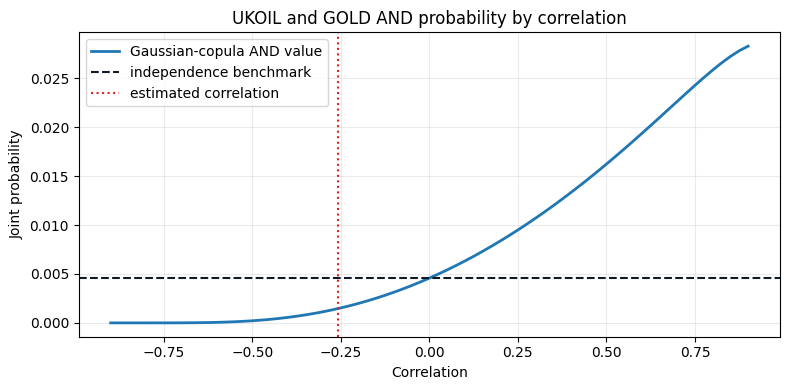

In [46]:
correlation_grid = np.linspace(-0.90, 0.90, 73)
joint_grid = [gaussian_and_probability(example_quote['probability_ukoil'],
                                       example_quote['probability_gold'], rho)
              for rho in correlation_grid]

fig, axis = plt.subplots(figsize=(8, 4))
axis.plot(correlation_grid, joint_grid, linewidth=2, label='Gaussian-copula AND value')
axis.axhline(example_quote['independence_probability'], color='#111827', linestyle='--',
             label='independence benchmark')
axis.axvline(example_quote['ewma_correlation'], color='#dc2626', linestyle=':',
             label='estimated correlation')
axis.set_xlabel('Correlation')
axis.set_ylabel('Joint probability')
axis.set_title('UKOIL and GOLD AND probability by correlation')
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

## Common-date settlement

The sample settlement function finds the most recent date on or before expiry for which both histories contain a valid Close. This keeps the two observations synchronized. A production contract should use an approved calendar and should not invent a fallback after the outcome is known.

In [47]:
def common_closes_on_or_before(ukoil_closes: pd.Series, gold_closes: pd.Series, expiry_date) -> dict:
    levels = pd.concat([
        _daily_close_by_date(ukoil_closes, 'UKOIL'),
        _daily_close_by_date(gold_closes, 'GOLD'),
    ], axis=1, join='inner').dropna()
    target = to_utc_timestamp(expiry_date).normalize()
    eligible = levels[levels.index <= target]
    if eligible.empty:
        raise ValueError('No valid common close exists on or before expiry')
    row = eligible.iloc[-1]
    return {'settlement_date': eligible.index[-1], 'UKOIL': float(row['UKOIL']), 'GOLD': float(row['GOLD'])}


def and_contract_payout(settlement_ukoil: float, strike_ukoil: float,
                        settlement_gold: float, strike_gold: float) -> float:
    return 1.0 if settlement_ukoil > strike_ukoil and settlement_gold > strike_gold else 0.0


demo_settlement = common_closes_on_or_before(
    MARKET_DATA['UKOIL'].daily_closes,
    MARKET_DATA['GOLD'].daily_closes,
    min(MARKET_DATA['UKOIL'].daily_closes.index[-1], MARKET_DATA['GOLD'].daily_closes.index[-1]),
)
demo_settlement['payout_at_example_strikes'] = and_contract_payout(
    demo_settlement['UKOIL'], example_strike_ukoil,
    demo_settlement['GOLD'], example_strike_gold,
)
display(pd.Series(demo_settlement, name='settlement demonstration'))

settlement_date              2026-10-05 00:00:00+00:00
UKOIL                                       100.320000
GOLD                                      4,156.799805
payout_at_example_strikes                     0.000000
Name: settlement demonstration, dtype: object

## Sanity checks

These checks cover the core product logic, probability bounds, dependence behavior, tick rounding, inventory direction, and strict settlement comparison.

In [48]:
p1, p2 = 0.40, 0.30
independent = gaussian_and_probability(p1, p2, 0.0)
assert math.isclose(independent, p1 * p2, rel_tol=0, abs_tol=1e-6)
assert gaussian_and_probability(p1, p2, 0.60) > independent
assert gaussian_and_probability(p1, p2, -0.60) < independent

lower, upper = frechet_bounds(p1, p2)
assert lower <= independent <= upper == min(p1, p2)
assert example_quote['frechet_lower_bound'] <= example_quote['fair_probability'] <= example_quote['frechet_upper_bound']
assert 0.0 <= example_quote['bid'] <= example_quote['ask'] <= 1.0
assert abs(example_quote['bid'] / TICK_SIZE - round(example_quote['bid'] / TICK_SIZE)) < 1e-8
assert abs(example_quote['ask'] / TICK_SIZE - round(example_quote['ask'] / TICK_SIZE)) < 1e-8

neutral_quote = make_combo_bid_ask(independent, p1, p2, 0.0, 0.25, inventory_yes=0)
long_yes_quote = make_combo_bid_ask(independent, p1, p2, 0.0, 0.25, inventory_yes=10)
assert long_yes_quote['quote_mid_after_inventory'] < neutral_quote['quote_mid_after_inventory']

assert and_contract_payout(101, 100, 201, 200) == 1.0
assert and_contract_payout(100, 100, 201, 200) == 0.0
assert and_contract_payout(101, 100, 200, 200) == 0.0
assert len(JOINT_ESTIMATE['paired_returns']) >= MIN_PAIRED_RETURNS

print('All Model 2 sanity checks passed.')

All Model 2 sanity checks passed.


## Limitations and next steps

- Historical EWMA volatility is not implied volatility. It misses option-market skew and forward-looking event risk.
- Historical correlation is not implied correlation and can break sharply during stress.
- The Gaussian copula has weak tail dependence. A Student-t copula is a sensible extension for fat-tailed joint outcomes.
- BZ=F and GC=F are rolling futures series. Roll jumps can contaminate returns and change the economic meaning of a long-dated contract.
- Rates, commodity carry, storage, convenience yield, and the futures curve are set aside.
- Yahoo Finance is not a production settlement oracle.
- The spread coefficients are transparent policy defaults, not coefficients calibrated from fills or hedging PnL.
- Cross-gamma is shown numerically, but a production desk would also stress gaps, basis, correlation vega, and hedge slippage.
- The Frechet check validates the model mid. Executable arbitrage requires synchronized single-leg and combo bid/ask books.
- Position limits, quote size, fees, latency, hedging, monitoring, and no-quote controls remain outside this notebook.

## Final summary

Model 2 reuses the Model 1 OHLC skeleton but prices the combo from a joint distribution. It estimates two marginal digital probabilities, connects them with an explicit correlation and Gaussian copula, verifies exact no-arbitrage bounds, then applies inventory and risk buffers to produce a bid and ask.

## Difference from Kalshi and Polymarket

This notebook is a pricing tool for one trader or market maker. It estimates the chance that both UKOIL and GOLD finish above their targets, then suggests a bid and ask. It does not run a real market.

Kalshi and Polymarket are full marketplaces. They publish the market rules, accept real orders from many traders, match buyers with sellers, manage the money backing each contract, and pay the winner after the result is known. Their live price comes from all the orders in the market, not from one model. This notebook could help a market maker decide what prices to place on those platforms, but it would be only one participant in the market.

## Model 1 versus Model 2 — simple summary

### Model 1

Model 1 prices one event on one asset:

```text
Will one asset finish above one strike?
```

It calculates one probability using the asset price, strike, expiry, and volatility, then places a simple fixed spread around that probability. Model 1 has one underlying, one strike, one marginal probability, EWMA historical volatility, a fixed two-cent half-spread, and no dependence or inventory model.

### Model 2

Model 2 prices a combined event:

```text
Will UKOIL finish above its strike AND GOLD finish above its strike?
```

It first calculates one probability for UKOIL and one for GOLD. It then estimates how the two assets move together and calculates the probability that both events happen at the same time.

### What Model 2 introduced

1. Two underlyings instead of one: UKOIL and GOLD are priced together.
2. A joint probability: the model estimates the chance that both events occur.
3. Correlation: the model recognizes that UKOIL and GOLD may move together.
4. A Gaussian copula: this connects the two marginal probabilities into one AND probability.
5. Frechet no-arbitrage bounds: the combo probability cannot exceed the less likely leg.
6. Correlation stress: the model tests the effect of correlation being wrong by about 0.10.
7. Dynamic spreads: the spread widens for correlation uncertainty, near-strike risk, and short expiry.
8. Inventory skew: quotes move down when the market maker is long YES and up when short YES.
9. A maximum inventory skew: inventory cannot move the quote by more than five cents.
10. Cross-gamma diagnostics: the notebook measures sensitivity when both assets move together.
11. Common-date settlement: both legs use the same expiry-date settlement convention.

### Main difference

**Model 1 asks: ‘What is the chance that one event happens?’ Model 2 asks: ‘What is the chance that two related events happen together?’** Model 2 is therefore the better structure for an AND contract, although its accuracy still depends on the quality of its volatility, correlation, settlement, and spread assumptions.